# CNN — Classificação de Árvores Binárias (2 classes)

Classes: `balanceada` | `nao_balanceada`

In [16]:
from google.colab import drive
import os

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("Drive já montado.")

Drive já montado.


## Imports e seed

In [17]:
import os, shutil, math, random, time
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    mean_squared_error, roc_auc_score,
    ConfusionMatrixDisplay,
    precision_score, f1_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configurações

In [18]:
IMAGE_SIZE  = (128, 128)
BATCH_SIZE  = 8
EPOCHS      = 100
LR          = 1e-3

CAMINHO_TRABALHO = "/content/drive/MyDrive/Sistemas Inteligentes - Trabalho"
DATASET_ROOT     = f"{CAMINHO_TRABALHO}/dataset"
SPLIT_DIR        = f"{CAMINHO_TRABALHO}/dataset_split_final"

PASTAS_NAO_BAL = [
    "desbalanceadas_direita",
    "desbalanceadas_esquerda",
    "pendentes_direita",
    "pendentes_esquerda",
]

CLASSES     = ["balanceada", "nao_balanceada"]
NUM_CLASSES = 2

## Split 70 / 10 / 20


In [19]:
def copy_with_retry(src, dst, retries=5, delay=3):
    for attempt in range(retries):
        try:
            shutil.copy2(src, dst)
            return
        except OSError:
            if attempt < retries - 1:
                print(f"    [retry {attempt+1}] aguardando {delay}s...")
                time.sleep(delay)
            else:
                raise

def split_dataset(dataset_root, dst_root, pastas_nao_bal, seed=SEED):
    if os.path.exists(dst_root):
        print("Recriando split para garantir integridade...")
        shutil.rmtree(dst_root)

    for split in ("train", "val", "test"):
        for cls in ("balanceada", "nao_balanceada"):
            os.makedirs(os.path.join(dst_root, split, cls), exist_ok=True)

    def coletar(pasta_path):
        arquivos = [f for f in os.listdir(pasta_path)
                    if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        random.Random(seed).shuffle(arquivos)
        return arquivos

    def distribuir(lista_src_nome, cls_nome):
        random.Random(seed).shuffle(lista_src_nome)
        n     = len(lista_src_nome)
        n_tr  = math.floor(n * 0.70)
        n_val = math.floor(n * 0.10)
        buckets = {
            "train": lista_src_nome[:n_tr],
            "val"  : lista_src_nome[n_tr:n_tr + n_val],
            "test" : lista_src_nome[n_tr + n_val:],
        }
        for split, lista in buckets.items():
            for pasta, nome in lista:
                copy_with_retry(
                    os.path.join(pasta, nome),
                    os.path.join(dst_root, split, cls_nome, nome),
                )
        print(f"  {cls_nome.upper()}: {n_tr} treino | {n_val} val | {n - n_tr - n_val} teste  (total={n})")
        return n_tr, n_val, n - n_tr - n_val

    bal_pasta = os.path.join(dataset_root, "balanceadas")
    bal_imgs  = [(bal_pasta, f) for f in coletar(bal_pasta)]
    n_tr_bal, n_val_bal, n_test_bal = distribuir(bal_imgs, "balanceada")

    nao_bal_imgs = []
    for pasta in pastas_nao_bal:
        caminho = os.path.join(dataset_root, pasta)
        for f in coletar(caminho):
            nao_bal_imgs.append((caminho, f))
    random.Random(seed).shuffle(nao_bal_imgs)

    total_bal = n_tr_bal + n_val_bal + n_test_bal
    nao_bal_imgs = nao_bal_imgs[:total_bal]
    distribuir(nao_bal_imgs, "nao_balanceada")

split_dataset(DATASET_ROOT, SPLIT_DIR, PASTAS_NAO_BAL)

Recriando split para garantir integridade...
  BALANCEADA: 35 treino | 5 val | 10 teste  (total=50)
  NAO_BALANCEADA: 35 treino | 5 val | 10 teste  (total=50)


## Geradores com Data Augmentation


In [21]:
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,
    horizontal_flip    = True,
    rotation_range     = 25,
    zoom_range         = 0.25,
    width_shift_range  = 0.20,
    height_shift_range = 0.20,
    shear_range        = 0.15,
    brightness_range   = [0.60, 1.40],
    fill_mode          = "nearest",
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

def make_gen(datagen, split, shuffle):
    return datagen.flow_from_directory(
        os.path.join(SPLIT_DIR, split),
        target_size = IMAGE_SIZE,
        color_mode  = "grayscale",
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        seed        = SEED,
        shuffle     = shuffle,
    )

train_gen = make_gen(train_datagen,    "train", shuffle=True)
val_gen   = make_gen(val_test_datagen, "val",   shuffle=False)
test_gen  = make_gen(val_test_datagen, "test",  shuffle=False)

print(f"Classes: {train_gen.class_indices}")
print(f"Treino: {train_gen.samples} | Val: {val_gen.samples} | Teste: {test_gen.samples}")

Found 70 images belonging to 2 classes.
Found 10 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Classes: {'balanceada': 0, 'nao_balanceada': 1}
Treino: 70 | Val: 10 | Teste: 20


### Amostras com augmentation

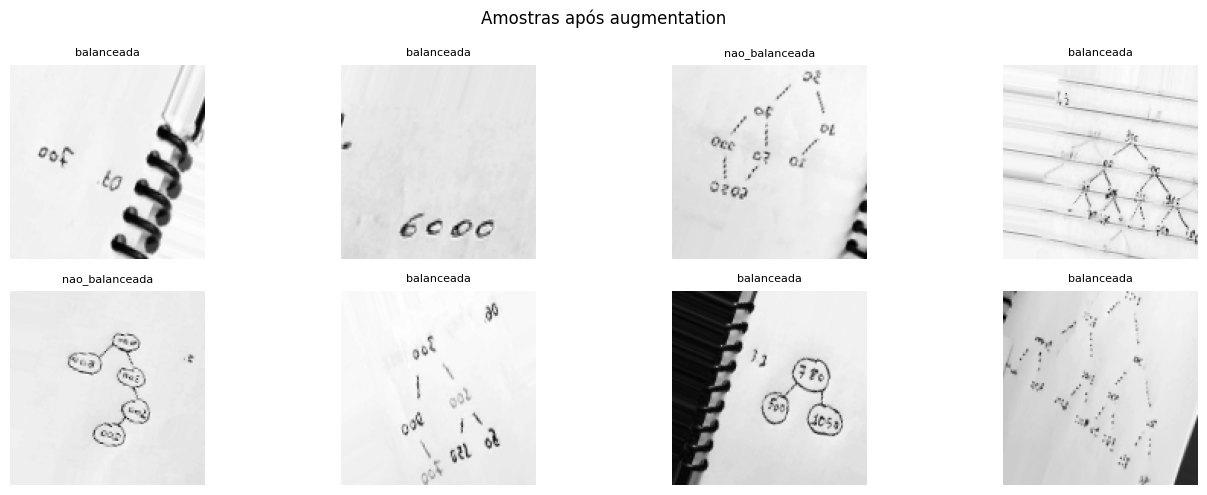

In [22]:
def plot_augmented_samples(gen, n=8):
    gen.reset()
    imgs, labels = next(gen)
    n = min(n, len(imgs))
    class_names = list(gen.class_indices.keys())
    fig, axes = plt.subplots(2, max(1, n // 2), figsize=(14, 5))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis("off")
            continue
        ax.imshow(imgs[i].squeeze(), cmap="gray")
        ax.set_title(class_names[int(labels[i])], fontsize=8)
        ax.axis("off")
    plt.suptitle("Amostras após augmentation")
    plt.tight_layout()
    plt.show()

plot_augmented_samples(train_gen)

## Class Weights

In [23]:
pesos = compute_class_weight(
    class_weight = "balanced",
    classes      = np.array([0, 1]),
    y            = train_gen.classes,
)
class_weights = dict(enumerate(pesos))
print("Class weights:", class_weights)
print("Índices das classes:", train_gen.class_indices)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Índices das classes: {'balanceada': 0, 'nao_balanceada': 1}


## Arquitetura CNN

In [24]:
def build_model(input_shape=(128, 128, 1)):
    inp = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Conv2D(64, 3, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Flatten()(x)

    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.40)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inp, out, name="CNN_ArvoresBinarias")
    return model

model = build_model(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1))

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR),
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"],
)

model.summary()

Model: "CNN_ArvoresBinarias"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,129 (16.36 MB)

 Trainable params: 4,287,681 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Treinamento

In [25]:
MODELO_PATH = f"{CAMINHO_TRABALHO}/melhor_modelo_final.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODELO_PATH,
        monitor="val_loss", save_best_only=True, verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=30,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=10,
        min_lr=1e-7, verbose=1,
    ),
]

history = model.fit(
    train_gen,
    epochs          = EPOCHS,
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = callbacks,
    verbose         = 1,
)

Epoch 1/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - accuracy: 0.6123 - loss: 7.7278
Epoch 1: val_loss improved from None to 0.72391, saving model to /content/drive/MyDrive/Sistemas Inteligentes - Trabalho/melhor_modelo_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Sistemas Inteligentes - Trabalho/melhor_modelo_final.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5429 - loss: 8.3516 - val_accuracy: 0.5000 - val_loss: 0.7239 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5397 - loss: 8.8739
Epoch 2: val_loss did not improve from 0.72391
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.5000 - loss: 8.4516 - val_accuracy: 0.6000 - val_loss: 0.7324 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3709 - loss: 8.4698
Epoch 3: val_loss did not improve from 0.72391
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.4714 - loss: 8.2700 - val_accuracy: 0.5000 - val_loss: 0.7880 

## Curvas de aprendizado

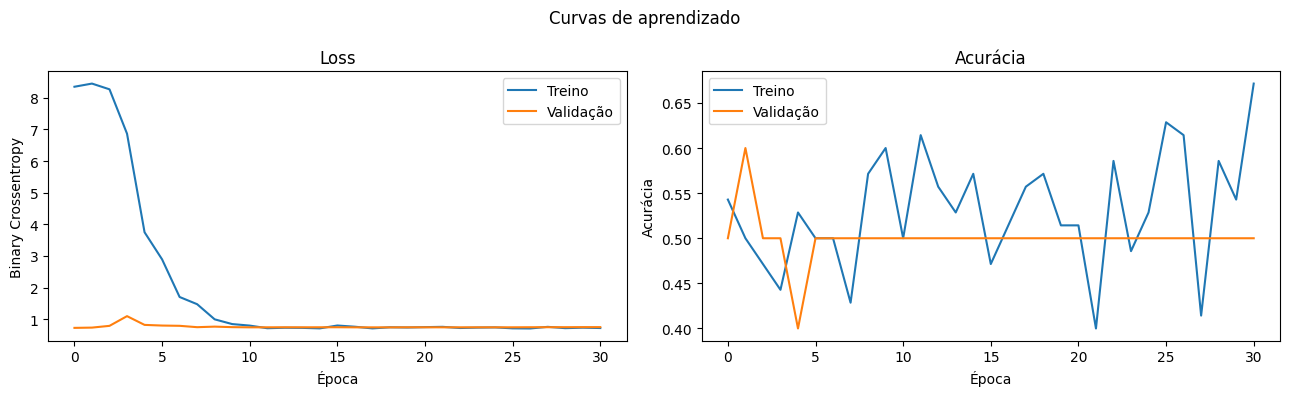

In [26]:
def plot_history(h):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(h.history["loss"],     label="Treino")
    ax1.plot(h.history["val_loss"], label="Validação")
    ax1.set_title("Loss")
    ax1.set_xlabel("Época")
    ax1.set_ylabel("Binary Crossentropy")
    ax1.legend()

    ax2.plot(h.history["accuracy"],     label="Treino")
    ax2.plot(h.history["val_accuracy"], label="Validação")
    ax2.set_title("Acurácia")
    ax2.set_xlabel("Época")
    ax2.set_ylabel("Acurácia")
    ax2.legend()

    plt.suptitle("Curvas de aprendizado", fontsize=12)
    plt.tight_layout()
    plt.show()

plot_history(history)

## Avaliação no teste

In [27]:
model = keras.models.load_model(MODELO_PATH)

test_gen.reset()
y_prob = model.predict(test_gen, verbose=1).flatten()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

loss_t, acc_t = model.evaluate(test_gen, verbose=0)
print("\nDesempenho Global")
print(f"  Loss  (teste): {loss_t:.4f}")
print(f"  Acurácia (teste): {acc_t:.4f}  ({acc_t*100:.2f}%)")

precision_geral = precision_score(y_true, y_pred, average="macro")
f1_geral        = f1_score(y_true, y_pred, average="macro")
print(f"  Precisão Média: {precision_geral:.4f}  ({precision_geral*100:.2f}%)")
print(f"  F1-Score Médio: {f1_geral:.4f}  ({f1_geral*100:.2f}%)")

print("\nMétricas por Classe")
precision_cls = precision_score(y_true, y_pred, average=None)
f1_cls        = f1_score(y_true, y_pred, average=None)
for i, cls in enumerate(class_names):
    print(f"  {cls:<20} | Precisão = {precision_cls[i]:.3f} | F1-Score = {f1_cls[i]:.3f}")

print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=class_names))

1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 391ms/step

Desempenho Global
  Loss  (teste): 0.7407
  Acurácia (teste): 0.5000  (50.00%)
  Precisão Média: 0.2500  (25.00%)
  F1-Score Médio: 0.3333  (33.33%)

Métricas por Classe
  balanceada           | Precisão = 0.000 | F1-Score = 0.000
  nao_balanceada       | Precisão = 0.500 | F1-Score = 0.667

── Classification Report ──
                precision    recall  f1-score   support

    balanceada       0.00      0.00      0.00        10
nao_balanceada       0.50      1.00      0.67        10

      accuracy                           0.50        20
     macro avg       0.25      0.50      0.33        20
  weighted avg       0.25      0.50      0.33        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

## Exemplos de predições

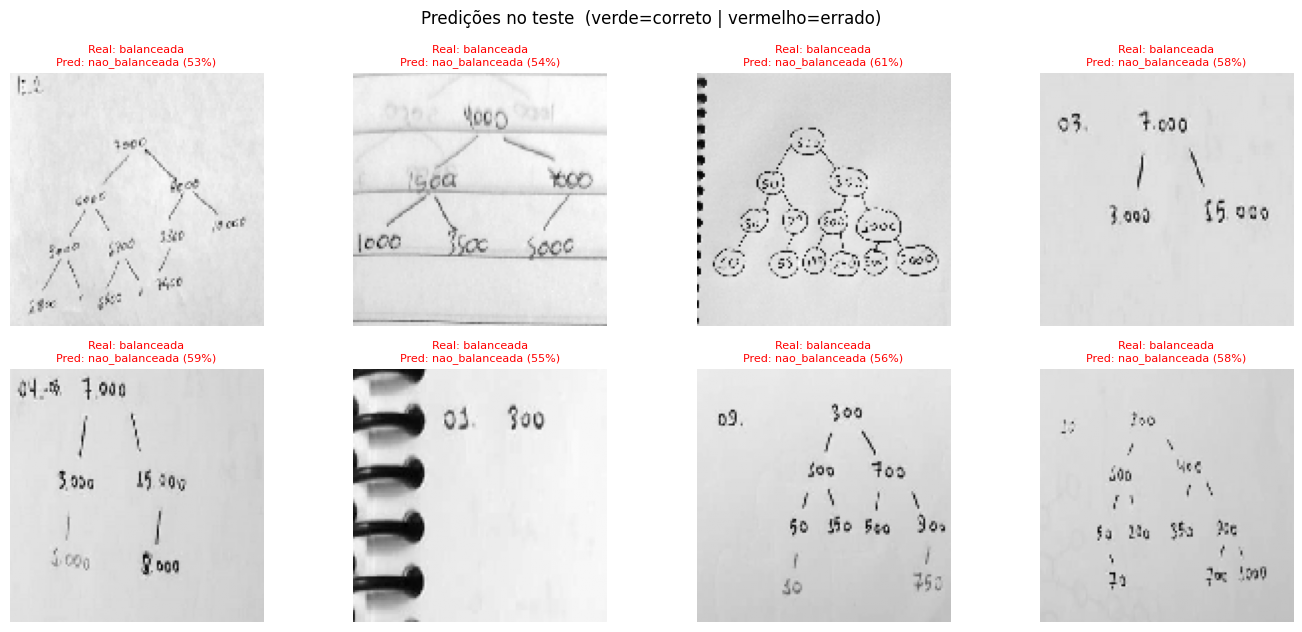


✔  Concluído.


In [30]:
def plot_predictions(gen, model, n=12):
    gen.reset()
    imgs, labels = next(gen)
    n = min(n, len(imgs))
    preds = model.predict(imgs, verbose=0).flatten()
    pred_classes = (preds >= 0.5).astype(int)
    class_names_local = list(gen.class_indices.keys())
    cols, rows = 4, math.ceil(n / 4)
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.2))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis("off")
            continue
        ax.imshow(imgs[i].squeeze(), cmap="gray")
        true_cls = class_names_local[int(labels[i])]
        pred_cls = class_names_local[pred_classes[i]]
        conf     = preds[i] if pred_classes[i] == 1 else 1 - preds[i]
        color    = "green" if true_cls == pred_cls else "red"
        ax.set_title(f"Real: {true_cls}\nPred: {pred_cls} ({conf:.0%})",
                     fontsize=8, color=color)
        ax.axis("off")
    plt.suptitle("Predições no teste  (verde=correto | vermelho=errado)")
    plt.tight_layout()
    plt.show()

plot_predictions(test_gen, model, n=12)